## **Customer Segmentation**

In [ ]:
segmen=pd.DataFrame({'Tenure Months':X_selected_test['Tenure Months'],'Monthly Charges':X_selected_test['Monthly Charges'],'Total Charges':X_selected_test['Total Charges']
                     ,'Churn Probab':churn_proba})
segmen

,Tenure Months,Monthly Charges,Total Charges,Churn Probab
185,15,85.90,1269.55,0.714923
2715,18,56.80,1074.65,0.321343
3825,2,20.00,40.90,0.252302
1807,6,84.20,519.15,0.842757
132,40,104.80,4131.95,0.493107
...,...,...,...,...
6366,66,104.90,6891.45,0.150097
315,19,86.00,1532.45,0.708425
2439,2,90.35,190.50,0.735418
5002,68,110.20,7467.50,0.071416


## **K means**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
Scaler=StandardScaler()

In [ ]:
scaled_data=Scaler.fit_transform(segmen)

In [ ]:
print(scaled_data[:5])

[[-0.69631406  0.6691038  -0.45048988  1.13284836]
 [-0.57429095 -0.31419848 -0.53600108 -0.17058408]
 [-1.22508089 -1.55768728 -0.98955267 -0.39922819]
 [-1.0623834   0.61166002 -0.77972336  1.55619913]
 [ 0.32054522  1.30774342  0.80537089  0.39825135]]


In [ ]:
from sklearn.cluster import KMeans

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

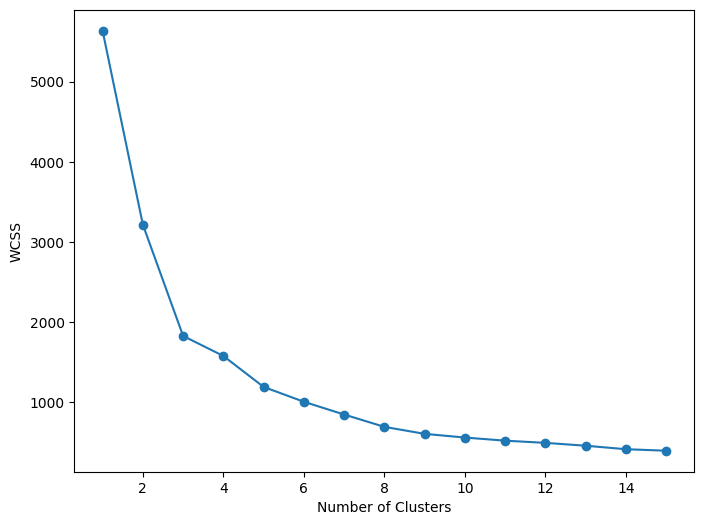

In [ ]:
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)
clusters=kmeans.fit_predict(scaled_data)
print(clusters)

[0 1 1 ... 0 2 0]


In [ ]:
segmen['Cluster']=clusters

In [ ]:
segmen

,Tenure Months,Monthly Charges,Total Charges,Churn Probab,Cluster
185,15,85.90,1269.55,0.714923,0
2715,18,56.80,1074.65,0.321343,1
3825,2,20.00,40.90,0.252302,1
1807,6,84.20,519.15,0.842757,0
132,40,104.80,4131.95,0.493107,2
...,...,...,...,...,...
6366,66,104.90,6891.45,0.150097,2
315,19,86.00,1532.45,0.708425,0
2439,2,90.35,190.50,0.735418,0
5002,68,110.20,7467.50,0.071416,2


In [ ]:
cluster_summary=segmen.groupby('Cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probab
Cluster,,,,
0,11.009276,73.629499,892.334230,0.685314
1,32.164786,33.281941,1085.465801,0.134568
2,58.718970,90.638173,5324.795550,0.225646


In [ ]:
cluster_summary={0:"Budget and Loyal",1:"High Risk Churn",2:"Premiun and Loyal"}

In [ ]:
segmen['Cluster Updated']=segmen['Cluster'].map(cluster_summary)

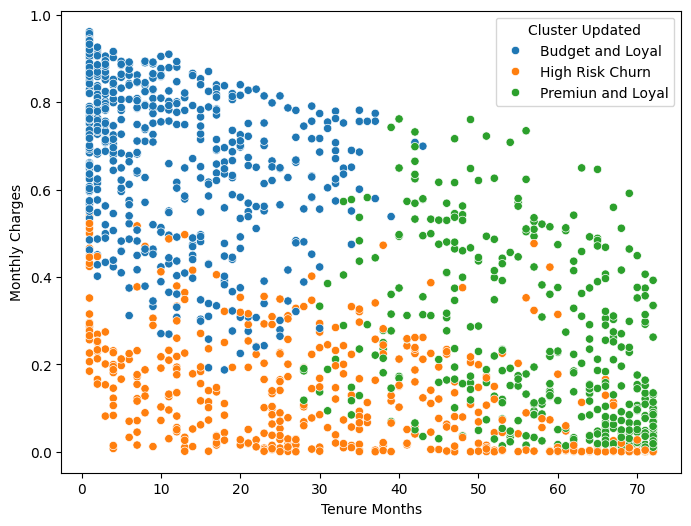

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months',y='Churn Probab',hue='Cluster Updated',data=segmen)
plt.xlabel("Tenure Months")
plt.ylabel("Monthly Charges")
plt.show()

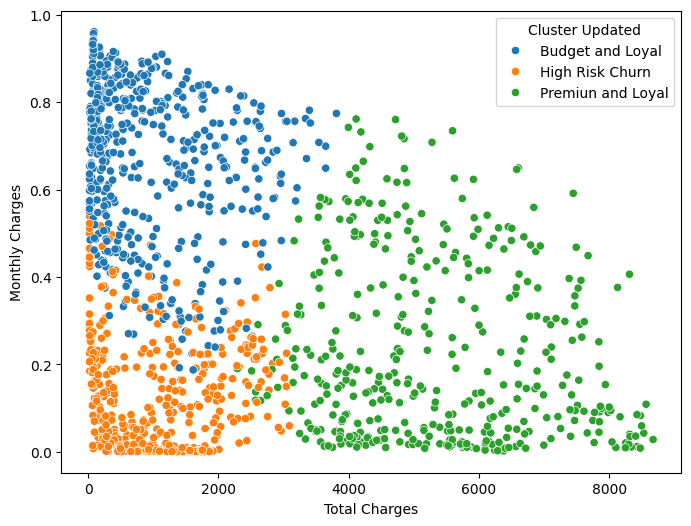

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Charges',y='Churn Probab',hue='Cluster Updated',data=segmen)
plt.xlabel("Total Charges")
plt.ylabel("Monthly Charges")
plt.show()